<a href="https://colab.research.google.com/github/watermelonripeness-thesis/Watermelon-Audio-Model/blob/main/model_training_from_eda_no_undersample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model Training & Hyperparameter Comparison (EDA-Based Features, NO UNDERSAMPLING)

Trains and tunes 7 classifiers -- Naive Bayes, SVM, Decision Tree, Random
Forest, XGBoost, Logistic Regression, KNN -- on the feature set produced
by `preprocess_from_eda_no_undersample.ipynb` (spectral centroid/bandwidth/
rolloff, zero-crossing rate, RMS, and 13 MFCC coefficients' mean+std -- 31
features total). **Train set keeps its natural class imbalance** -- no
undersampling was applied upstream, so compare these results against the
undersampled run to see how much of the earlier performance came from
balancing versus the features/model themselves.

For each classifier: fit with **default** hyperparameters, then run a
**randomized hyperparameter search** (5-fold stratified CV, scoring=F1)
and fit the **tuned** best estimator. Both are evaluated on the same
untouched, held-out test set. Produces:
  - one comparison table (default vs. tuned), plus a ranked summary
  - a hyperparameter comparison table (default vs. tuned values)
  - a grouped bar chart of tuned-model metrics
  - a metrics heatmap (all models x all metrics, one glance)
  - a radar chart comparing all 7 tuned models holistically
  - a default-vs-tuned F1 comparison chart
  - an ROC curve plot with all 7 classifiers overlaid
  - a Precision-Recall curve plot (more informative under class imbalance)
  - a confusion matrix grid
  - feature importance charts for the tree-based models (RF, DT, XGBoost) --
    useful for checking whether known-suspect features (e.g. spectral
    centroid, mfcc2/mfcc3) are driving predictions


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install xgboost --quiet

In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_curve, auc,
                              precision_recall_curve, average_precision_score,
                              confusion_matrix)
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from scipy.stats import loguniform

RANDOM_STATE = 42
DATA_DIR = "/content/drive/MyDrive/Watermelon Data/z. csv"

np.random.seed(RANDOM_STATE)

## Load features

Reads the CSVs produced by `preprocess_from_eda_no_undersample.ipynb`.
All columns except `filename` and `label` are used as features (5
spectral/time-domain descriptors + 13 MFCC coefficients x 2 statistics
= 31 features). The train set here keeps its natural, real-world class
imbalance -- it was not undersampled upstream.


In [ ]:
train_df = pd.read_csv(os.path.join(DATA_DIR, "train_features_no_undersample.csv"))
test_df = pd.read_csv(os.path.join(DATA_DIR, "test_features_no_undersample.csv"))

FEATURE_COLS = [c for c in train_df.columns if c not in ("filename", "label")]

n_train, n_test = len(train_df), len(test_df)
n_total = n_train + n_test
print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"Total samples: {n_total}  (Train: {n_train} [{n_train/n_total:.1%}], "
      f"Test: {n_test} [{n_test/n_total:.1%}])")
print(f"Train class balance: {train_df['label'].value_counts().to_dict()}")
print(f"Test class balance:  {test_df['label'].value_counts().to_dict()}")
print(f"Number of features: {len(FEATURE_COLS)}")
print("=" * 60)
print()
print("NOTE: train set is NOT balanced -- natural class ratio is kept "
      "on purpose (this is the no-undersampling run).")


DATASET SUMMARY
Total samples: 494  (Train: 395 [80.0%], Test: 99 [20.0%])
Train class balance: {'unripe': 271, 'ripe': 124}
Test class balance:  {'unripe': 68, 'ripe': 31}
Number of features: 31

NOTE: train set is NOT balanced -- natural class ratio is kept on purpose (this is the no-undersampling run).


## Classifiers and hyperparameter search spaces

`RandomizedSearchCV` with 5-fold stratified CV, scored on F1, `n_iter=25`
draws per classifier (NB's single parameter uses a plain grid since its
search space is tiny).

In [ ]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
N_ITER = 60  # default draws per classifier; a few models override this below

MODELS = {
    "Naive Bayes": {
        "estimator": GaussianNB(),
        "param_dist": {
            "var_smoothing": np.logspace(-12, -6, 200),
        },
        "n_iter": 60,
    },
    "Support Vector Machine": {
        "estimator": SVC(probability=True, random_state=RANDOM_STATE),
        "param_dist": {
            "C": loguniform(1e-3, 1e3),
            "kernel": ["linear", "rbf", "poly", "sigmoid"],
            "gamma": loguniform(1e-4, 1e1),
            "degree": [2, 3, 4, 5],
            "coef0": [0.0, 0.1, 0.5, 1.0],
            "class_weight": [None, "balanced"],
        },
        "n_iter": 100,
    },
    "Decision Tree": {
        "estimator": DecisionTreeClassifier(random_state=RANDOM_STATE),
        "param_dist": {
            "max_depth": [2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20, 25, None],
            "min_samples_split": [2, 3, 4, 5, 7, 10, 15, 20, 30],
            "min_samples_leaf": [1, 2, 3, 4, 5, 7, 10, 15],
            "criterion": ["gini", "entropy", "log_loss"],
            "max_features": ["sqrt", "log2", None, 0.5, 0.7, 0.9],
            "class_weight": [None, "balanced"],
        },
        "n_iter": 100,
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(random_state=RANDOM_STATE),
        "param_dist": {
            "n_estimators": [50, 100, 150, 200, 300, 400, 500, 700, 1000],
            "max_depth": [3, 4, 5, 6, 7, 8, 10, 12, 15, 20, None],
            "min_samples_split": [2, 3, 5, 7, 10, 15, 20],
            "min_samples_leaf": [1, 2, 3, 4, 5, 7, 10],
            "max_features": ["sqrt", "log2", None, 0.3, 0.5, 0.7, 0.9],
            "bootstrap": [True, False],
            "class_weight": [None, "balanced", "balanced_subsample"],
        },
        "n_iter": 150,
    },
    "XGBoost": {
        "estimator": XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE),
        "param_dist": {
            "n_estimators": [50, 100, 150, 200, 300, 400, 500, 700, 1000],
            "max_depth": [2, 3, 4, 5, 6, 7, 8, 10],
            "learning_rate": loguniform(0.005, 0.5),
            "subsample": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
            "colsample_bytree": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
            "colsample_bylevel": [0.5, 0.7, 0.9, 1.0],
            "min_child_weight": [1, 2, 3, 5, 7, 10],
            "gamma": [0, 0.01, 0.05, 0.1, 0.3, 0.5, 1.0],
            "reg_alpha": [0, 0.001, 0.01, 0.1, 1, 5],
            "reg_lambda": [0.1, 0.5, 1, 2, 5, 10],
        },
        "n_iter": 150,
    },
    "Logistic Regression": {
        "estimator": LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
        "param_dist": {
            "C": loguniform(1e-4, 1e3),
            "penalty": ["l1", "l2", "elasticnet"],
            "solver": ["liblinear", "saga"],
            "l1_ratio": [0.0, 0.15, 0.3, 0.5, 0.7, 0.85, 1.0],  # only used by elasticnet
            "class_weight": [None, "balanced"],
        },
        "n_iter": 100,
    },
    "K-Nearest Neighbors": {
        "estimator": KNeighborsClassifier(),
        "param_dist": {
            "n_neighbors": list(range(1, 32, 2)),
            "weights": ["uniform", "distance"],
            "metric": ["euclidean", "manhattan", "minkowski", "chebyshev"],
            "p": [1, 2, 3],
            "leaf_size": [10, 20, 30, 40, 50, 70, 100],
        },
        "n_iter": 100,
    },
}

## Core experiment function

In [ ]:
def evaluate(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }


def run_experiment(feature_cols, train_df=train_df, test_df=test_df):
    Xtr = train_df[feature_cols].values
    ytr = (train_df["label"] == "ripe").astype(int).values
    Xte = test_df[feature_cols].values
    yte = (test_df["label"] == "ripe").astype(int).values

    rows = []
    tuned_models = {}

    for name, cfg in MODELS.items():
        default_model = cfg["estimator"].__class__(**cfg["estimator"].get_params())
        default_model.fit(Xtr, ytr)
        pred_default = default_model.predict(Xte)
        param_keys = list(cfg["param_dist"].keys())
        default_params = {k: cfg["estimator"].get_params()[k] for k in param_keys}
        row_default = {"Model": name, "Type": "Default", "BestParams": str(default_params)}
        row_default.update(evaluate(yte, pred_default))
        rows.append(row_default)

        search = RandomizedSearchCV(
            cfg["estimator"], cfg["param_dist"],
            n_iter=cfg.get("n_iter", N_ITER),
            cv=CV, scoring="f1", random_state=RANDOM_STATE,
            n_jobs=-1, error_score=0.0,
        )
        search.fit(Xtr, ytr)
        best_model = search.best_estimator_
        pred_tuned = best_model.predict(Xte)
        row_tuned = {"Model": name, "Type": "Tuned", "BestParams": str(search.best_params_)}
        row_tuned.update(evaluate(yte, pred_tuned))
        rows.append(row_tuned)

        tuned_models[name] = best_model
        print(f"  {name}: default F1={row_default['F1']:.4f}  ->  tuned F1={row_tuned['F1']:.4f}")

    results_df = pd.DataFrame(rows)
    return results_df, tuned_models, (Xte, yte)


def show_hyperparams_table(results_df):
    hp_df = results_df.pivot(index="Model", columns="Type", values="BestParams").reset_index()
    hp_df = hp_df.rename(columns={"Default": "Default Hyperparameters",
                                   "Tuned": "Best (Tuned) Hyperparameters"})
    display(hp_df)
    return hp_df

## Plotting helpers

In [ ]:
def plot_metric_bars(results_df, title):
    tuned = results_df[results_df["Type"] == "Tuned"].set_index("Model")
    metrics = ["Accuracy", "Precision", "Recall", "F1"]
    x = np.arange(len(tuned.index))
    width = 0.2

    fig, ax = plt.subplots(figsize=(12, 6))
    for i, metric in enumerate(metrics):
        ax.bar(x + i * width, tuned[metric], width, label=metric)
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(tuned.index, rotation=20, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_default_vs_tuned(results_df, metric, title):
    pivot = results_df.pivot(index="Model", columns="Type", values=metric)
    pivot = pivot[["Default", "Tuned"]]
    x = np.arange(len(pivot.index))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(x - width / 2, pivot["Default"], width, label="Default", color="tab:gray")
    ax.bar(x + width / 2, pivot["Tuned"], width, label="Tuned", color="tab:blue")
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=20, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_roc_curves(tuned_models, Xte, yte, title):
    fig, ax = plt.subplots(figsize=(7, 6))
    colors = plt.cm.tab10(np.linspace(0, 1, len(tuned_models)))

    for (name, model), color in zip(tuned_models.items(), colors):
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(Xte)[:, 1]
        else:
            y_score = model.decision_function(Xte)
        fpr, tpr, _ = roc_curve(yte, y_score)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, label=f"{name} (AUC={roc_auc:.3f})")

    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    ax.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_pr_curves(tuned_models, Xte, yte, title):
    fig, ax = plt.subplots(figsize=(7, 6))
    colors = plt.cm.tab10(np.linspace(0, 1, len(tuned_models)))

    for (name, model), color in zip(tuned_models.items(), colors):
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(Xte)[:, 1]
        else:
            y_score = model.decision_function(Xte)
        precision, recall, _ = precision_recall_curve(yte, y_score)
        ap = average_precision_score(yte, y_score)
        ax.plot(recall, precision, color=color, label=f"{name} (AP={ap:.3f})")

    baseline = yte.mean()
    ax.axhline(baseline, linestyle="--", color="gray",
               label=f"Baseline (prevalence={baseline:.2f})")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(title)
    ax.legend(loc="lower left", fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrices(tuned_models, Xte, yte, title):
    n = len(tuned_models)
    ncols = 4
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, (name, model) in zip(axes, tuned_models.items()):
        pred = model.predict(Xte)
        cm = confusion_matrix(yte, pred)
        ax.imshow(cm, cmap="Blues")
        for (i, j), val in np.ndenumerate(cm):
            ax.text(j, i, str(val), ha="center", va="center",
                    color="white" if val > cm.max() / 2 else "black")
        ax.set_xticks([0, 1]); ax.set_xticklabels(["Unripe", "Ripe"])
        ax.set_yticks([0, 1]); ax.set_yticklabels(["Unripe", "Ripe"])
        ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
        ax.set_title(name, fontsize=10)

    for ax in axes[len(tuned_models):]:
        ax.axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

def plot_metrics_heatmap(results_df, title):
    tuned = results_df[results_df["Type"] == "Tuned"].set_index("Model")
    metrics = ["Accuracy", "Precision", "Recall", "F1"]
    data = tuned[metrics]

    fig, ax = plt.subplots(figsize=(7, 0.6 * len(data) + 1.5))
    im = ax.imshow(data.values, cmap="YlGnBu", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(metrics)))
    ax.set_xticklabels(metrics)
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels(data.index)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data.values[i, j]
            ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                    color="white" if val > 0.6 else "black", fontsize=9)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Score")
    plt.tight_layout()
    plt.show()


def plot_radar_chart(results_df, title):
    tuned = results_df[results_df["Type"] == "Tuned"].set_index("Model")
    metrics = ["Accuracy", "Precision", "Recall", "F1"]
    n_metrics = len(metrics)

    angles = np.linspace(0, 2 * np.pi, n_metrics, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    colors = plt.cm.tab10(np.linspace(0, 1, len(tuned.index)))

    for (name, row), color in zip(tuned.iterrows(), colors):
        values = row[metrics].tolist()
        values += values[:1]
        ax.plot(angles, values, color=color, linewidth=1.5, label=name)
        ax.fill(angles, values, color=color, alpha=0.08)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics)
    ax.set_ylim(0, 1)
    ax.set_title(title, y=1.08)
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_feature_importances(tuned_models, feature_cols, title, top_n=15):
    tree_models = {name: m for name, m in tuned_models.items()
                   if hasattr(m, "feature_importances_")}
    if not tree_models:
        print("No tree-based models with feature_importances_ found -- skipping.")
        return

    fig, axes = plt.subplots(1, len(tree_models), figsize=(6 * len(tree_models), 5))
    if len(tree_models) == 1:
        axes = [axes]

    for ax, (name, model) in zip(axes, tree_models.items()):
        importances = pd.Series(model.feature_importances_, index=feature_cols)
        importances = importances.sort_values(ascending=True).tail(top_n)
        ax.barh(importances.index, importances.values, color="tab:blue")
        ax.set_title(name, fontsize=11)
        ax.set_xlabel("Importance")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


---
## Run the experiment

In [ ]:
print("=== Training and tuning all 7 classifiers ===")
results, tuned_models, (Xte, yte) = run_experiment(FEATURE_COLS)

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)
print("\nFull comparison table:")
display(results.drop(columns=["BestParams"]).round(3))

=== Training and tuning all 7 classifiers ===
  Naive Bayes: default F1=0.9355  ->  tuned F1=0.9355
  Support Vector Machine: default F1=0.9492  ->  tuned F1=0.9667
  Decision Tree: default F1=0.9206  ->  tuned F1=0.9677
  Random Forest: default F1=0.9508  ->  tuned F1=0.9677
  XGBoost: default F1=0.9677  ->  tuned F1=0.9508
  Logistic Regression: default F1=0.9508  ->  tuned F1=0.9508
  K-Nearest Neighbors: default F1=0.9667  ->  tuned F1=0.9667

Full comparison table:


,Model,Type,Accuracy,Precision,Recall,F1
0,Naive Bayes,Default,0.960,0.935,0.935,0.935
1,Naive Bayes,Tuned,0.960,0.935,0.935,0.935
2,Support Vector Machine,Default,0.970,1.000,0.903,0.949
3,Support Vector Machine,Tuned,0.980,1.000,0.935,0.967
4,Decision Tree,Default,0.949,0.906,0.935,0.921
5,Decision Tree,Tuned,0.980,0.968,0.968,0.968
6,Random Forest,Default,0.970,0.967,0.935,0.951
7,Random Forest,Tuned,0.980,0.968,0.968,0.968
8,XGBoost,Default,0.980,0.968,0.968,0.968
9,XGBoost,Tuned,0.970,0.967,0.935,0.951


### Ranked summary (tuned models, sorted by F1)

Same numbers as above, just sorted so the best-performing classifier
for this dataset is immediately obvious at a glance.


In [ ]:
ranked = (results[results["Type"] == "Tuned"]
          .drop(columns=["BestParams", "Type"])
          .sort_values("F1", ascending=False)
          .reset_index(drop=True))
ranked.index = ranked.index + 1
ranked.index.name = "Rank"
display(ranked.round(3))


,Model,Accuracy,Precision,Recall,F1
Rank,,,,,
1,Decision Tree,0.98,0.968,0.968,0.968
2,Random Forest,0.98,0.968,0.968,0.968
3,Support Vector Machine,0.98,1.000,0.935,0.967
4,K-Nearest Neighbors,0.98,1.000,0.935,0.967
5,XGBoost,0.97,0.967,0.935,0.951
6,Logistic Regression,0.97,0.967,0.935,0.951
7,Naive Bayes,0.96,0.935,0.935,0.935


In [ ]:
print("Hyperparameters -- default vs. tuned:")
hp_df = show_hyperparams_table(results)

Hyperparameters -- default vs. tuned:


Type,Model,Default Hyperparameters,Best (Tuned) Hyperparameters
0,Decision Tree,"{'max_depth': None, 'min_samples_split': 2, 'm...","{'min_samples_split': 5, 'min_samples_leaf': 1..."
1,K-Nearest Neighbors,"{'n_neighbors': 5, 'weights': 'uniform', 'metr...","{'weights': 'distance', 'p': 2, 'n_neighbors':..."
2,Logistic Regression,"{'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs',...","{'C': np.float64(0.4369946783595577), 'class_w..."
3,Naive Bayes,{'var_smoothing': 1e-09},{'var_smoothing': np.float64(7.316807143427177...
4,Random Forest,"{'n_estimators': 100, 'max_depth': None, 'min_...","{'n_estimators': 200, 'min_samples_split': 3, ..."
5,Support Vector Machine,"{'C': 1.0, 'kernel': 'rbf', 'gamma': 'scale', ...","{'C': np.float64(150.8761367568167), 'class_we..."
6,XGBoost,"{'n_estimators': None, 'max_depth': None, 'lea...","{'colsample_bylevel': 0.5, 'colsample_bytree':..."


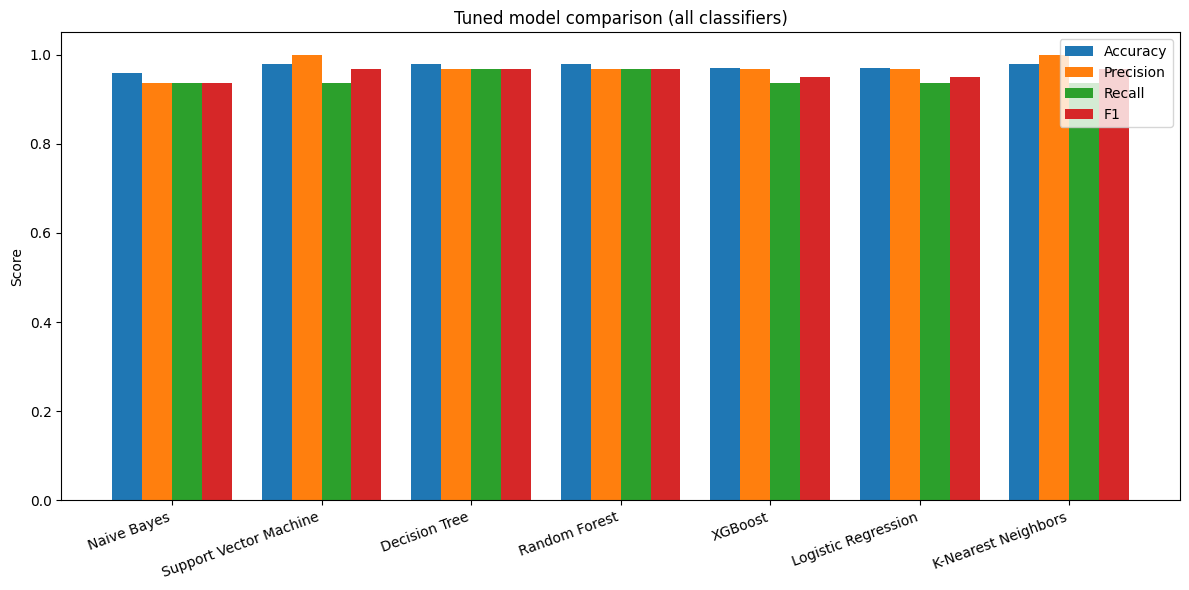

In [ ]:
plot_metric_bars(results, "Tuned model comparison (all classifiers)")

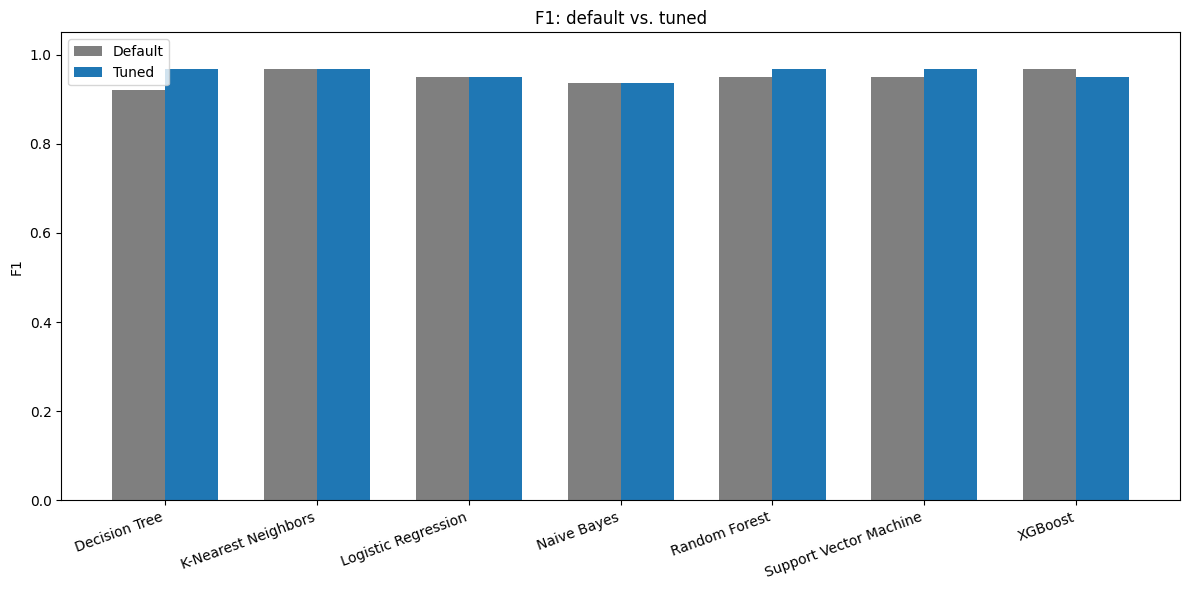

In [ ]:
plot_default_vs_tuned(results, "F1", "F1: default vs. tuned")

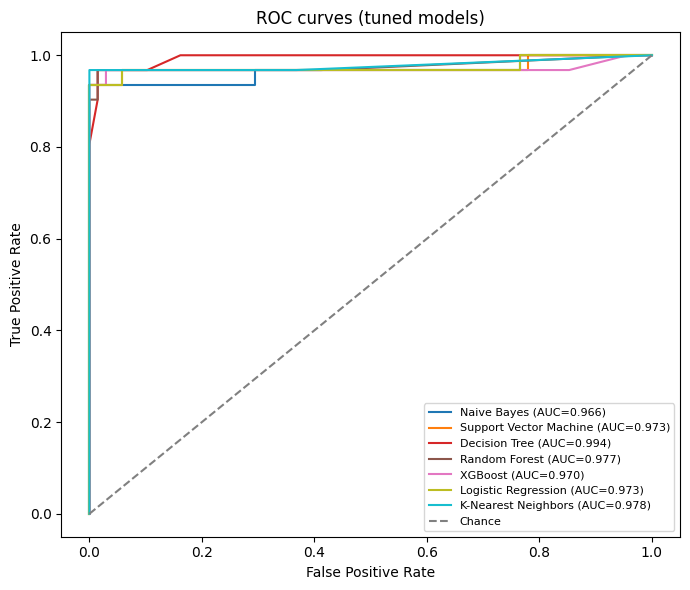

In [ ]:
plot_roc_curves(tuned_models, Xte, yte, "ROC curves (tuned models)")

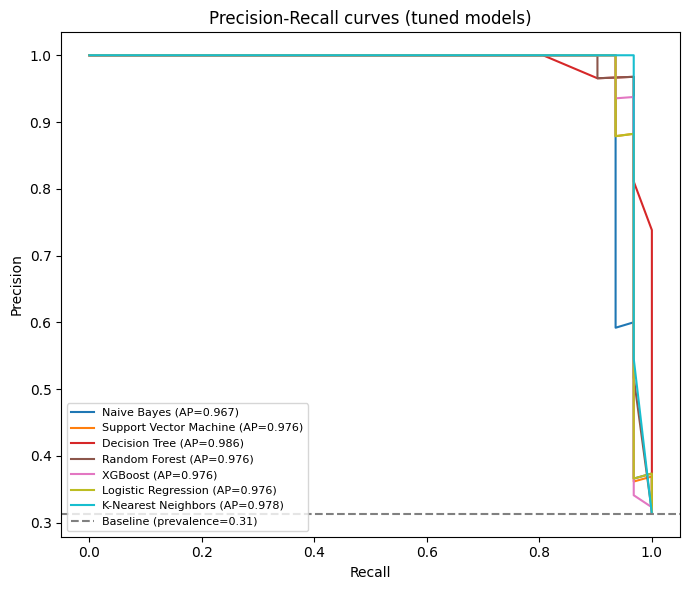

In [ ]:
plot_pr_curves(tuned_models, Xte, yte, "Precision-Recall curves (tuned models)")

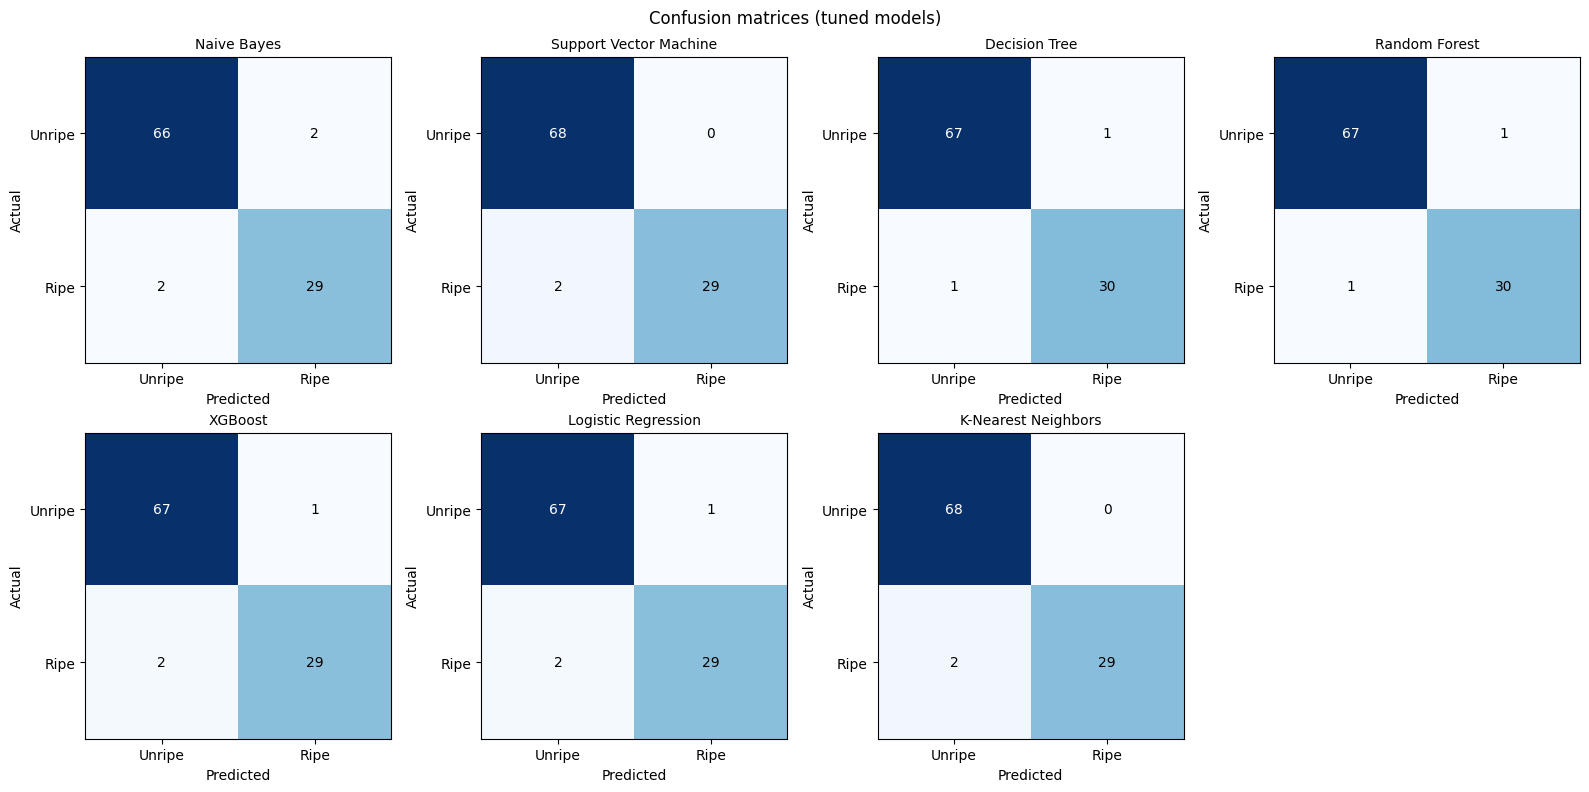

In [ ]:
plot_confusion_matrices(tuned_models, Xte, yte, "Confusion matrices (tuned models)")

### Metrics heatmap

All models, all metrics, one glance -- easier to scan than the bar
chart when you just want to spot the best/worst cells quickly.


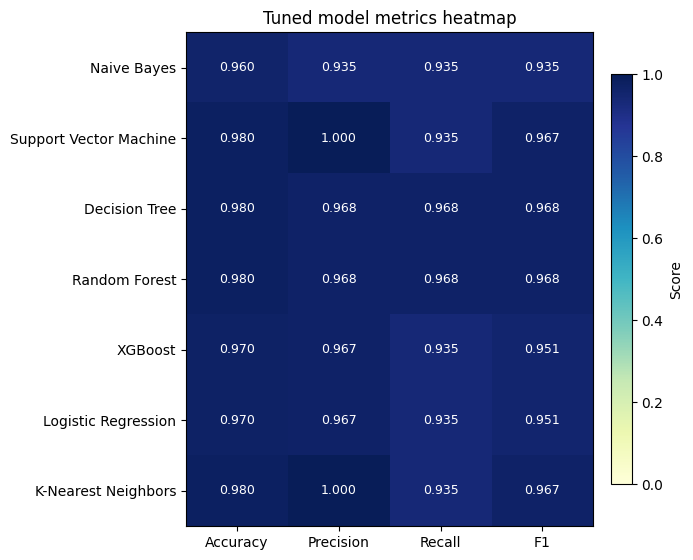

In [ ]:
plot_metrics_heatmap(results, "Tuned model metrics heatmap")


### Feature importances (tree-based models)

Worth checking against the confound findings from EDA -- if the
top-ranked features here are the ones already flagged as suspect
(`spectral_centroid`, `mfcc2_mean`, `mfcc3_mean`, etc.), that's a sign
the classifier may still be leaning on recording-environment artifacts
rather than genuine ripeness acoustics.


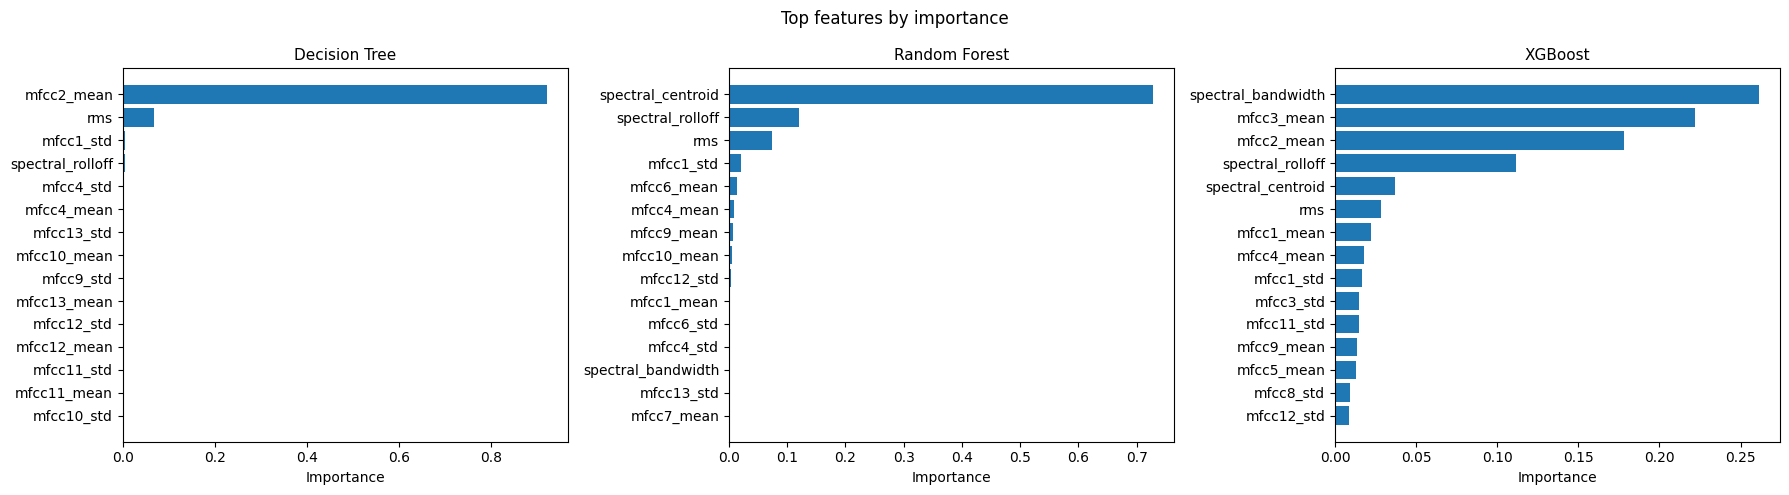

In [ ]:
plot_feature_importances(tuned_models, FEATURE_COLS, "Top features by importance")


## Save results

In [ ]:
results.to_csv(os.path.join(DATA_DIR, "model_comparison_results.csv"), index=False)
print("Saved model_comparison_results.csv")

Saved model_comparison_results.csv
